In [2]:
import pandas as pd

## Load regional ERCOT datasets

Read each pre-saved regional CSV from `data/regional_data/` into a dedicated DataFrame for modeling.

In [3]:
from pathlib import Path

# Directory holding regional CSV exports from the trade notebook
REGIONAL_DATA_DIR = Path("data/regional_data")

# Individual regional panels
df_coast = pd.read_csv(REGIONAL_DATA_DIR / "coast.csv")
df_south = pd.read_csv(REGIONAL_DATA_DIR / "south.csv")
df_west  = pd.read_csv(REGIONAL_DATA_DIR / "west.csv")
df_north = pd.read_csv(REGIONAL_DATA_DIR / "north.csv")
df_east  = pd.read_csv(REGIONAL_DATA_DIR / "east.csv")

# All regions stacked into a single panel (if needed for pooled models)
df_all_regions = pd.read_csv(REGIONAL_DATA_DIR / "all_regions.csv")

In [4]:
df_all_regions.columns

Index(['Unnamed: 0', 'wind_gen_total_mw', 'wind_gen_west_mw',
       'wind_gen_north_mw', 'wind_gen_south_mw', 'wind_gen_coast_mw',
       'wind_gen_panhandle_mw', 'solar_gen_total_mw', 'solar_gen_west_mw',
       'solar_gen_north_mw', 'solar_gen_east_mw', 'solar_gen_south_mw',
       'solar_gen_coast_mw', 'COAST_Load', 'EAST_Load', 'ERCOT_Load',
       'LZ_HOUSTON_DAM', 'LZ_NORTH_DAM', 'LZ_RAYBN_DAM', 'LZ_SOUTH_DAM',
       'LZ_WEST_DAM', 'NORTH_Load', 'SOUTH_Load', 'WEST_Load', 'altimeter_C',
       'altimeter_E', 'altimeter_N', 'altimeter_S', 'altimeter_W',
       'dew_point_temperature_C', 'dew_point_temperature_E',
       'dew_point_temperature_N', 'dew_point_temperature_S',
       'dew_point_temperature_W', 'holiday', 'month', 'relative_humidity_C',
       'relative_humidity_E', 'relative_humidity_N', 'relative_humidity_S',
       'relative_humidity_W', 'temperature_C', 'temperature_E',
       'temperature_N', 'temperature_S', 'temperature_W', 'visibility_C',
       'visibility_E

In [5]:
def clean_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    """
    Renames the 'Unnamed: 0' column to 'datetime',
    parses it as a datetime, and sets it as the DataFrame index.

    Parameters
    ----------
    df : pd.DataFrame
        Regional DataFrame with an 'Unnamed: 0' timestamp column.

    Returns
    -------
    pd.DataFrame
        Cleaned DataFrame with a proper datetime index.
    """
    return (
        df.rename(columns={'Unnamed: 0': 'datetime'})
          .assign(datetime=lambda x: pd.to_datetime(x['datetime']))
          .set_index('datetime')
    )


# ── apply to all regional dfs ──────────────────────────────────────────────
df_coast      = clean_datetime_index(df_coast)
df_south      = clean_datetime_index(df_south)
df_west       = clean_datetime_index(df_west)
df_north      = clean_datetime_index(df_north)
df_east       = clean_datetime_index(df_east)
df_all_regions = clean_datetime_index(df_all_regions)

In [14]:
df_coast.columns

Index(['COAST_Load', 'LZ_HOUSTON_DAM', 'wind_gen_coast_mw',
       'solar_gen_coast_mw', 'altimeter_C', 'dew_point_temperature_C',
       'relative_humidity_C', 'temperature_C', 'visibility_C', 'holiday',
       'weekend', 'month', 'Year', 'ERCOT_Load', 'wind_gen_total_mw',
       'solar_gen_total_mw', 'spread_h_s', 'spread_h_w', 'spread_h_n',
       'spread_h_r'],
      dtype='object')

Load zone prices: load-weighted average of the RT LMP across all electrical buses assigned to that zone.

Do we know how many electrical buses exist within each respective 

ERCOT South Load Zone LMP Calculation

The Real-Time Locational Marginal Price (LMP) for the South Load Zone for a specific SCED interval $y$ is calculated as a load-weighted average of the prices at all Electrical Buses within that zone:$$LZLMP_{South, y} = \sum_{b \in \text{South}} (RTLMP_{b, y} \times LZWF_{b, y})$$1. Calculating the Weighting Factor ($LZWF$)For all non-DC Tie Load Zones (like the South Zone), the weight of an individual bus is its share of the total zonal load:$$LZWF_{b, y} = \frac{SEL_{b, y}}{\sum_{b \in \text{South}} SEL_{b, y}}$$

Variable Definitions for South Load Zone LMP


LZLMP South y: South Load Zone Locational Marginal Price ($/MWh) – The final calculated price for the South Load Zone during a specific SCED interval.

RTLMP b, y: Real-Time Locational Marginal Price at bus ($/MWh) – The specific price at one individual Electrical Bus (b) within the South Load Zone for a specific interval.

LZWF b, y: Load Zone State Estimator Load Weighting Factor (None) – The specific "weight" or percentage assigned to an Electrical Bus (b) based on its share of the total zone load.

SEL b, y: State Estimator Load at bus (MW) – The amount of power being consumed at an Electrical Bus (b). This is the value used to determine the bus's weight in the final price.

y: SCED Interval (None) – The specific 5-minute real-time market time period being calculated.

b: Electrical Bus (None) – An individual electrical node or connection point within the South Load Zone boundary.

The Day-Ahead South Load Zone FormulaThe Day-Ahead Settlement Point Price ($DASPP$) for a Load Zone is the load-weighted average of the Day-Ahead LMPs at all energized buses in that zone:$$DASPP_{South, h} = \sum_{b} (DALMP_{b, h} \times LDF_{b, h})$$

Variable Definitions (No Math Symbols)

DASPP South h: Day-Ahead Settlement Point Price ($/MWh) – The final hourly price for the South Load Zone for a specific hour (h) of the following day.

DALMP b, h: Day-Ahead Locational Marginal Price ($/MWh) – The price calculated during the Day-Ahead Market at an individual Electrical Bus (b) for hour (h). This is based on bids and offers rather than real-time physics.

LDF b, h: Load Distribution Factor (None) – A decimal (percentage) representing the forecasted share of the total Load Zone's demand that will occur at Electrical Bus (b) during hour (h).

h: Operating Hour (None) – The specific one-hour block for which the price is being set (e.g., Hour Ending 14:00).

b: Electrical Bus (None) – An individual electrical node within the South Load Zone.

1. The Mathematical Formulas

South Load Zone LMP:$$LZLMP_{South} = \lambda - \sum_{c} (SP_{c} \times ZSF_{South, c})$$North Load Zone LMP:$$LZLMP_{North} = \lambda - \sum_{c} (SP_{c} \times ZSF_{North, c})$$


2. The Subtraction (The Spread)

When we subtract the North price from the South price, the System Lambda ($\lambda$) cancels out because it is identical for both zones:$$LZLMP_{South} - LZLMP_{North} = \left( \lambda - \sum_{c} (SP_{c} \times ZSF_{South, c}) \right) - \left( \lambda - \sum_{c} (SP_{c} \times ZSF_{North, c}) \right)$$This simplifies to the Congestion Spread:$$LZLMP_{South} - LZLMP_{North} = \sum_{c} \left[ SP_{c} \times (ZSF_{North, c} - ZSF_{South, c}) \right]$$

The result of this subtraction gives us the Relative Congestion Cost.

Here is how to interpret it:

If the result is Positive ($>0$): The South Zone is more expensive than the North Zone. This usually happens because the South is Downstream of a bottleneck, requiring more expensive local generation to meet demand.

If the result is Zero ($=0$): There is no congestion between the North and South. Power is flowing freely, and both zones are paying the exact same price (the System Lambda).

The "Why" Factor: Because the energy price ($\lambda$) is gone, the result proves that price differences in ERCOT are caused 100% by transmission constraints.

4.  Directional Flow: The term $(ZSF_{North, c} - ZSF_{South, c})$ identifies which zone is "pushing" more against a specific constraint. If the North has a much higher shift factor for a line than the South, the North price will be lower (upstream), and the South price will be higher (downstream).

In [7]:
df_all_regions.columns

Index(['wind_gen_total_mw', 'wind_gen_west_mw', 'wind_gen_north_mw',
       'wind_gen_south_mw', 'wind_gen_coast_mw', 'wind_gen_panhandle_mw',
       'solar_gen_total_mw', 'solar_gen_west_mw', 'solar_gen_north_mw',
       'solar_gen_east_mw', 'solar_gen_south_mw', 'solar_gen_coast_mw',
       'COAST_Load', 'EAST_Load', 'ERCOT_Load', 'LZ_HOUSTON_DAM',
       'LZ_NORTH_DAM', 'LZ_RAYBN_DAM', 'LZ_SOUTH_DAM', 'LZ_WEST_DAM',
       'NORTH_Load', 'SOUTH_Load', 'WEST_Load', 'altimeter_C', 'altimeter_E',
       'altimeter_N', 'altimeter_S', 'altimeter_W', 'dew_point_temperature_C',
       'dew_point_temperature_E', 'dew_point_temperature_N',
       'dew_point_temperature_S', 'dew_point_temperature_W', 'holiday',
       'month', 'relative_humidity_C', 'relative_humidity_E',
       'relative_humidity_N', 'relative_humidity_S', 'relative_humidity_W',
       'temperature_C', 'temperature_E', 'temperature_N', 'temperature_S',
       'temperature_W', 'visibility_C', 'visibility_E', 'visibility_N',
  

In [8]:
import itertools

# List of zone suffixes from your DF
zones = {'SOUTH': 's', 'NORTH': 'n', 'HOUSTON': 'h', 'WEST': 'w', 'RAYBN': 'r'}

# Create the 20 directional spread columns
for (name1, short1), (name2, short2) in itertools.permutations(zones.items(), 2):
    col_name = f"spread_{short1}_{short2}"
    df_all_regions[col_name] = df_all_regions[f"LZ_{name1}_DAM"] - df_all_regions[f"LZ_{name2}_DAM"]

In [9]:
df_all_regions.columns

Index(['wind_gen_total_mw', 'wind_gen_west_mw', 'wind_gen_north_mw',
       'wind_gen_south_mw', 'wind_gen_coast_mw', 'wind_gen_panhandle_mw',
       'solar_gen_total_mw', 'solar_gen_west_mw', 'solar_gen_north_mw',
       'solar_gen_east_mw', 'solar_gen_south_mw', 'solar_gen_coast_mw',
       'COAST_Load', 'EAST_Load', 'ERCOT_Load', 'LZ_HOUSTON_DAM',
       'LZ_NORTH_DAM', 'LZ_RAYBN_DAM', 'LZ_SOUTH_DAM', 'LZ_WEST_DAM',
       'NORTH_Load', 'SOUTH_Load', 'WEST_Load', 'altimeter_C', 'altimeter_E',
       'altimeter_N', 'altimeter_S', 'altimeter_W', 'dew_point_temperature_C',
       'dew_point_temperature_E', 'dew_point_temperature_N',
       'dew_point_temperature_S', 'dew_point_temperature_W', 'holiday',
       'month', 'relative_humidity_C', 'relative_humidity_E',
       'relative_humidity_N', 'relative_humidity_S', 'relative_humidity_W',
       'temperature_C', 'temperature_E', 'temperature_N', 'temperature_S',
       'temperature_W', 'visibility_C', 'visibility_E', 'visibility_N',
  

In [10]:
def create_regional_dfs(data: pd.DataFrame) -> dict[str, pd.DataFrame]:
    """
    Splits the master ERCOT DAM DataFrame into regional DataFrames,
    adding 4 price spreads AND regional/total renewable generation features.
    """
    
    # Mapping for price spread logic: { 'region_key': ('Price_Col', 'short_code') }
    mapping = {
        'coast': ('LZ_HOUSTON_DAM', 'h'),
        'south': ('LZ_SOUTH_DAM', 's'),
        'west': ('LZ_WEST_DAM', 'w'),
        'north': ('LZ_NORTH_DAM', 'n'),
        'east': ('LZ_RAYBN_DAM', 'r')
    }

    # Features shared by every single regional DataFrame
    shared_cols = [
        'holiday', 'weekend', 'month', 'Year', 'ERCOT_Load', 
        'wind_gen_total_mw', 'solar_gen_total_mw'
    ]

    # Region-specific mapping including Load, Price, Weather, and Renewables
    region_cols = {
        'coast': [
            'COAST_Load', 'LZ_HOUSTON_DAM', 'wind_gen_coast_mw', 'solar_gen_coast_mw',
            'altimeter_C', 'dew_point_temperature_C', 'relative_humidity_C', 'temperature_C', 'visibility_C'
        ],
        'south': [
            'SOUTH_Load', 'LZ_SOUTH_DAM', 'wind_gen_south_mw', 'solar_gen_south_mw',
            'altimeter_S', 'dew_point_temperature_S', 'relative_humidity_S', 'temperature_S', 'visibility_S'
        ],
        'west': [
            'WEST_Load', 'LZ_WEST_DAM', 'wind_gen_west_mw', 'solar_gen_west_mw', 'wind_gen_panhandle_mw',
            'altimeter_W', 'dew_point_temperature_W', 'relative_humidity_W', 'temperature_W', 'visibility_W'
        ],
        'north': [
            'NORTH_Load', 'LZ_NORTH_DAM', 'wind_gen_north_mw', 'solar_gen_north_mw', 'wind_gen_panhandle_mw',
            'altimeter_N', 'dew_point_temperature_N', 'relative_humidity_N', 'temperature_N', 'visibility_N'
        ],
        'east': [
            'EAST_Load', 'LZ_RAYBN_DAM', 'solar_gen_east_mw', # East/Rayburn has solar but no specific wind col in your list
            'altimeter_E', 'dew_point_temperature_E', 'relative_humidity_E', 'temperature_E', 'visibility_E'
        ],
    }

    regional_dfs = {}

    for region, cols in region_cols.items():
        all_cols = cols + shared_cols
        
        # Check for missing columns
        available_cols = [c for c in all_cols if c in data.columns]
        missing = set(all_cols) - set(available_cols)
        if missing:
            print(f"[INFO] {region.upper()} skipping missing: {list(missing)}")

        # Create the regional slice
        df_reg = data[available_cols].copy()
        
        # Calculate the 4 directional spreads
        curr_price_col, curr_code = mapping[region]
        for other_region, (other_price_col, other_code) in mapping.items():
            if region == other_region:
                continue
            
            spread_name = f"spread_{curr_code}_{other_code}"
            df_reg[spread_name] = data[curr_price_col] - data[other_price_col]

        regional_dfs[region] = df_reg

    return regional_dfs

In [11]:
container = create_regional_dfs(df_all_regions)


df_coast = container['coast']
df_south = container['south']
df_west  = container['west']
df_north = container['north']
df_east  = container['east']

In [12]:
df_south.columns

Index(['SOUTH_Load', 'LZ_SOUTH_DAM', 'wind_gen_south_mw', 'solar_gen_south_mw',
       'altimeter_S', 'dew_point_temperature_S', 'relative_humidity_S',
       'temperature_S', 'visibility_S', 'holiday', 'weekend', 'month', 'Year',
       'ERCOT_Load', 'wind_gen_total_mw', 'solar_gen_total_mw', 'spread_s_h',
       'spread_s_w', 'spread_s_n', 'spread_s_r'],
      dtype='object')

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Create figure with shared axes
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

spreads = [
    ('spread_s_h', 'South vs. Houston', 'tab:blue'),
    ('spread_s_w', 'South vs. West', 'tab:orange'),
    ('spread_s_n', 'South vs. North', 'tab:green'),
    ('spread_s_r', 'South vs. Rayburn', 'tab:red')
]

# 2. Iterate through subplots
for i, (col, title, color) in enumerate(spreads):
    ax = axes[i // 2, i % 2]
    
    ax.plot(df_south.index, df_south[col], color=color, linewidth=1.2)
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.4)
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.5)
    
    # --- X-Axis Formatting ---
    # Set the format to 'Abbreviated Month Year'
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    # Set the locator (e.g., every 2 months) to keep it clean
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

# 3. Final Styling
axes[0, 0].set_ylabel('Price Spread ($/MWh)', fontsize=11)
axes[1, 0].set_ylabel('Price Spread ($/MWh)', fontsize=11)

plt.suptitle('South Zone Price Spreads: Monthly Timeline', fontsize=16, y=0.98)

# Automatically rotates the 'Month Year' labels so they fit perfectly
fig.autofmt_xdate()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

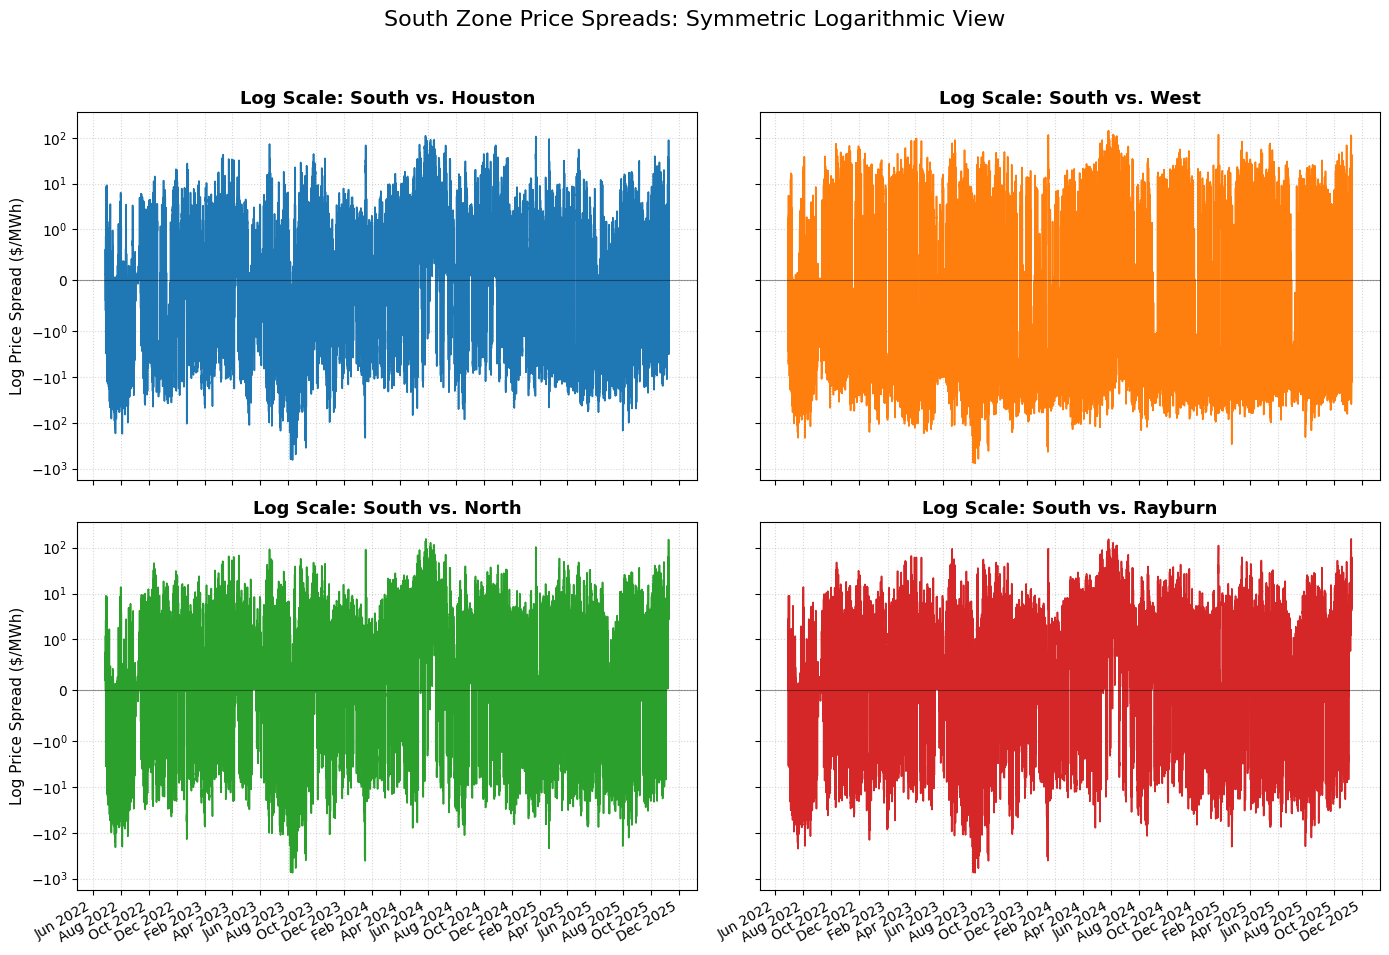

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Create figure with shared axes
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

spreads = [
    ('spread_s_h', 'South vs. Houston', 'tab:blue'),
    ('spread_s_w', 'South vs. West', 'tab:orange'),
    ('spread_s_n', 'South vs. North', 'tab:green'),
    ('spread_s_r', 'South vs. Rayburn', 'tab:red')
]

# 2. Iterate through subplots
for i, (col, title, color) in enumerate(spreads):
    ax = axes[i // 2, i % 2]
    
    ax.plot(df_south.index, df_south[col], color=color, linewidth=1.2)
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.4)
    
    # --- The Log Transformation ---
    # We use 'symlog' because spreads can be negative.
    # linthresh defines the range [-1, 1] within which the plot is linear.
    ax.set_yscale('symlog', linthresh=1.0)
    
    ax.set_title(f"Log Scale: {title}", fontsize=13, fontweight='bold')
    ax.grid(True, which="both", linestyle=':', alpha=0.5)
    
    # X-Axis: Month and Year only
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

# 3. Final Styling
axes[0, 0].set_ylabel('Log Price Spread ($/MWh)', fontsize=11)
axes[1, 0].set_ylabel('Log Price Spread ($/MWh)', fontsize=11)

plt.suptitle('South Zone Price Spreads: Symmetric Logarithmic View', fontsize=16, y=0.98)
fig.autofmt_xdate()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

In [ ]:
pip install shap


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
df_south.columns

Index(['SOUTH_Load', 'LZ_SOUTH_DAM', 'wind_gen_south_mw', 'solar_gen_south_mw',
       'altimeter_S', 'dew_point_temperature_S', 'relative_humidity_S',
       'temperature_S', 'visibility_S', 'holiday', 'weekend', 'month', 'Year',
       'ERCOT_Load', 'wind_gen_total_mw', 'solar_gen_total_mw', 'spread_s_h',
       'spread_s_w', 'spread_s_n', 'spread_s_r'],
      dtype='object')

In [ ]:
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt

# Region key -> load col, weather suffix, wind/solar cols, and spread column prefix (h,s,w,n,r)
REGION_CONFIG = {
    'coast': {'load': 'COAST_Load', 'suffix': 'C', 'wind': 'wind_gen_coast_mw', 'solar': 'solar_gen_coast_mw', 'spread_prefix': 'h'},
    'south': {'load': 'SOUTH_Load', 'suffix': 'S', 'wind': 'wind_gen_south_mw', 'solar': 'solar_gen_south_mw', 'spread_prefix': 's'},
    'west':  {'load': 'WEST_Load', 'suffix': 'W', 'wind': 'wind_gen_west_mw',  'solar': 'solar_gen_west_mw',  'spread_prefix': 'w'},
    'north': {'load': 'NORTH_Load', 'suffix': 'N', 'wind': 'wind_gen_north_mw', 'solar': 'solar_gen_north_mw', 'spread_prefix': 'n'},
    'east':  {'load': 'EAST_Load', 'suffix': 'E', 'wind': 'wind_gen_east_mw',  'solar': 'solar_gen_east_mw',  'spread_prefix': 'r'},
}


def _compute_region_spread_importances(df, target, region_key):
    """Compute XGBoost importances for one spread; returns (model, importances DataFrame)."""
    cfg = REGION_CONFIG.get(region_key)
    if not cfg:
        raise ValueError(f"Unknown region_key: {region_key}. Use one of {list(REGION_CONFIG)}")
    df = df.copy()
    load_col = cfg['load']
    suffix = cfg['suffix']
    wind_col = cfg['wind']
    solar_col = cfg['solar']
    net_load_name = load_col.replace('_Load', '_Net_Load')
    if load_col in df.columns and wind_col in df.columns and solar_col in df.columns:
        df[net_load_name] = df[load_col] - (df[wind_col] + df[solar_col])
    if isinstance(df.index, pd.DatetimeIndex):
        df['hour'] = df.index.hour
    feature_cols = [
        load_col, 'ERCOT_Load', net_load_name,
        wind_col, solar_col, 'wind_gen_total_mw', 'solar_gen_total_mw',
        f'temperature_{suffix}', f'dew_point_temperature_{suffix}', f'relative_humidity_{suffix}',
        'month', 'hour', 'weekend', 'holiday'
    ]
    feature_cols = [c for c in feature_cols if c in df.columns]
    df_clean = df[feature_cols + [target]].dropna()
    X = df_clean[feature_cols]
    y = df_clean[target]
    model = xgb.XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        importance_type='gain', random_state=42
    )
    model.fit(X, y)
    importances = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    return model, importances


def analyze_region_spread_drivers(df, target, region_key, ax=None):
    """
    Analyzes drivers for one spread in one region. If ax is provided, plots on it
    (for grid); otherwise creates a new figure and calls plt.show().
    """
    model, importances = _compute_region_spread_importances(df, target, region_key)
    # Descending importance -> first = highest at top (matplotlib barh: first y = top)
    if ax is not None:
        ax.barh(importances['Feature'], importances['Importance'], color='darkblue')
        ax.set_title(f'{target}', fontsize=10)
        ax.set_xlabel('Importance (Gain)')
        ax.grid(axis='x', linestyle=':', alpha=0.7)
    else:
        plt.figure(figsize=(10, 8))
        plt.barh(importances['Feature'], importances['Importance'], color='darkblue')
        plt.title(f'Key Drivers: {target}', fontsize=14)
        plt.xlabel('Importance (Gain Score)')
        plt.grid(axis='x', linestyle=':', alpha=0.7)
        plt.tight_layout()
        plt.show()
    return model, importances


def analyze_all_regions_spread_drivers(container):
    """
    container: dict mapping region name -> DataFrame (e.g. {'coast': df_coast, 'south': df_south, ...})
    Produces one figure: 5 rows (regions) x 4 columns (spreads per region), 20 visualizations total.
    """
    REGION_ORDER = ['coast', 'south', 'west', 'north', 'east']
    # 1) Compute all importances once
    grid_importances = [[None] * 4 for _ in range(5)]
    grid_titles = [[None] * 4 for _ in range(5)]
    for row, region_name in enumerate(REGION_ORDER):
        if region_name not in container:
            continue
        df_reg = container[region_name]
        cfg = REGION_CONFIG[region_name]
        prefix = cfg['spread_prefix']
        spread_cols = sorted([c for c in df_reg.columns if c.startswith(f'spread_{prefix}_')])
        if len(spread_cols) > 4:
            spread_cols = spread_cols[:4]
        for col, target in enumerate(spread_cols):
            _, imp = _compute_region_spread_importances(df_reg, target, region_name)
            grid_importances[row][col] = imp
            grid_titles[row][col] = target
    # 2) Matplotlib: highest importance at top (DataFrame is already descending, first row = top)
    fig, axes = plt.subplots(5, 4, figsize=(20, 24))
    for row in range(5):
        for col in range(4):
            imp = grid_importances[row][col]
            if imp is not None:
                axes[row, col].barh(imp['Feature'], imp['Importance'], color='darkblue')
                axes[row, col].set_title(grid_titles[row][col], fontsize=10)
                axes[row, col].set_xlabel('Importance (Gain)')
                axes[row, col].grid(axis='x', linestyle=':', alpha=0.7)
            else:
                axes[row, col].set_visible(False)
    for row, region_name in enumerate(REGION_ORDER):
        axes[row, 0].set_ylabel(region_name.capitalize(), fontsize=12)
    plt.suptitle('Spread drivers by region (5 rows × 4 spreads)', fontsize=14, y=1.002)
    plt.tight_layout()
    plt.show()

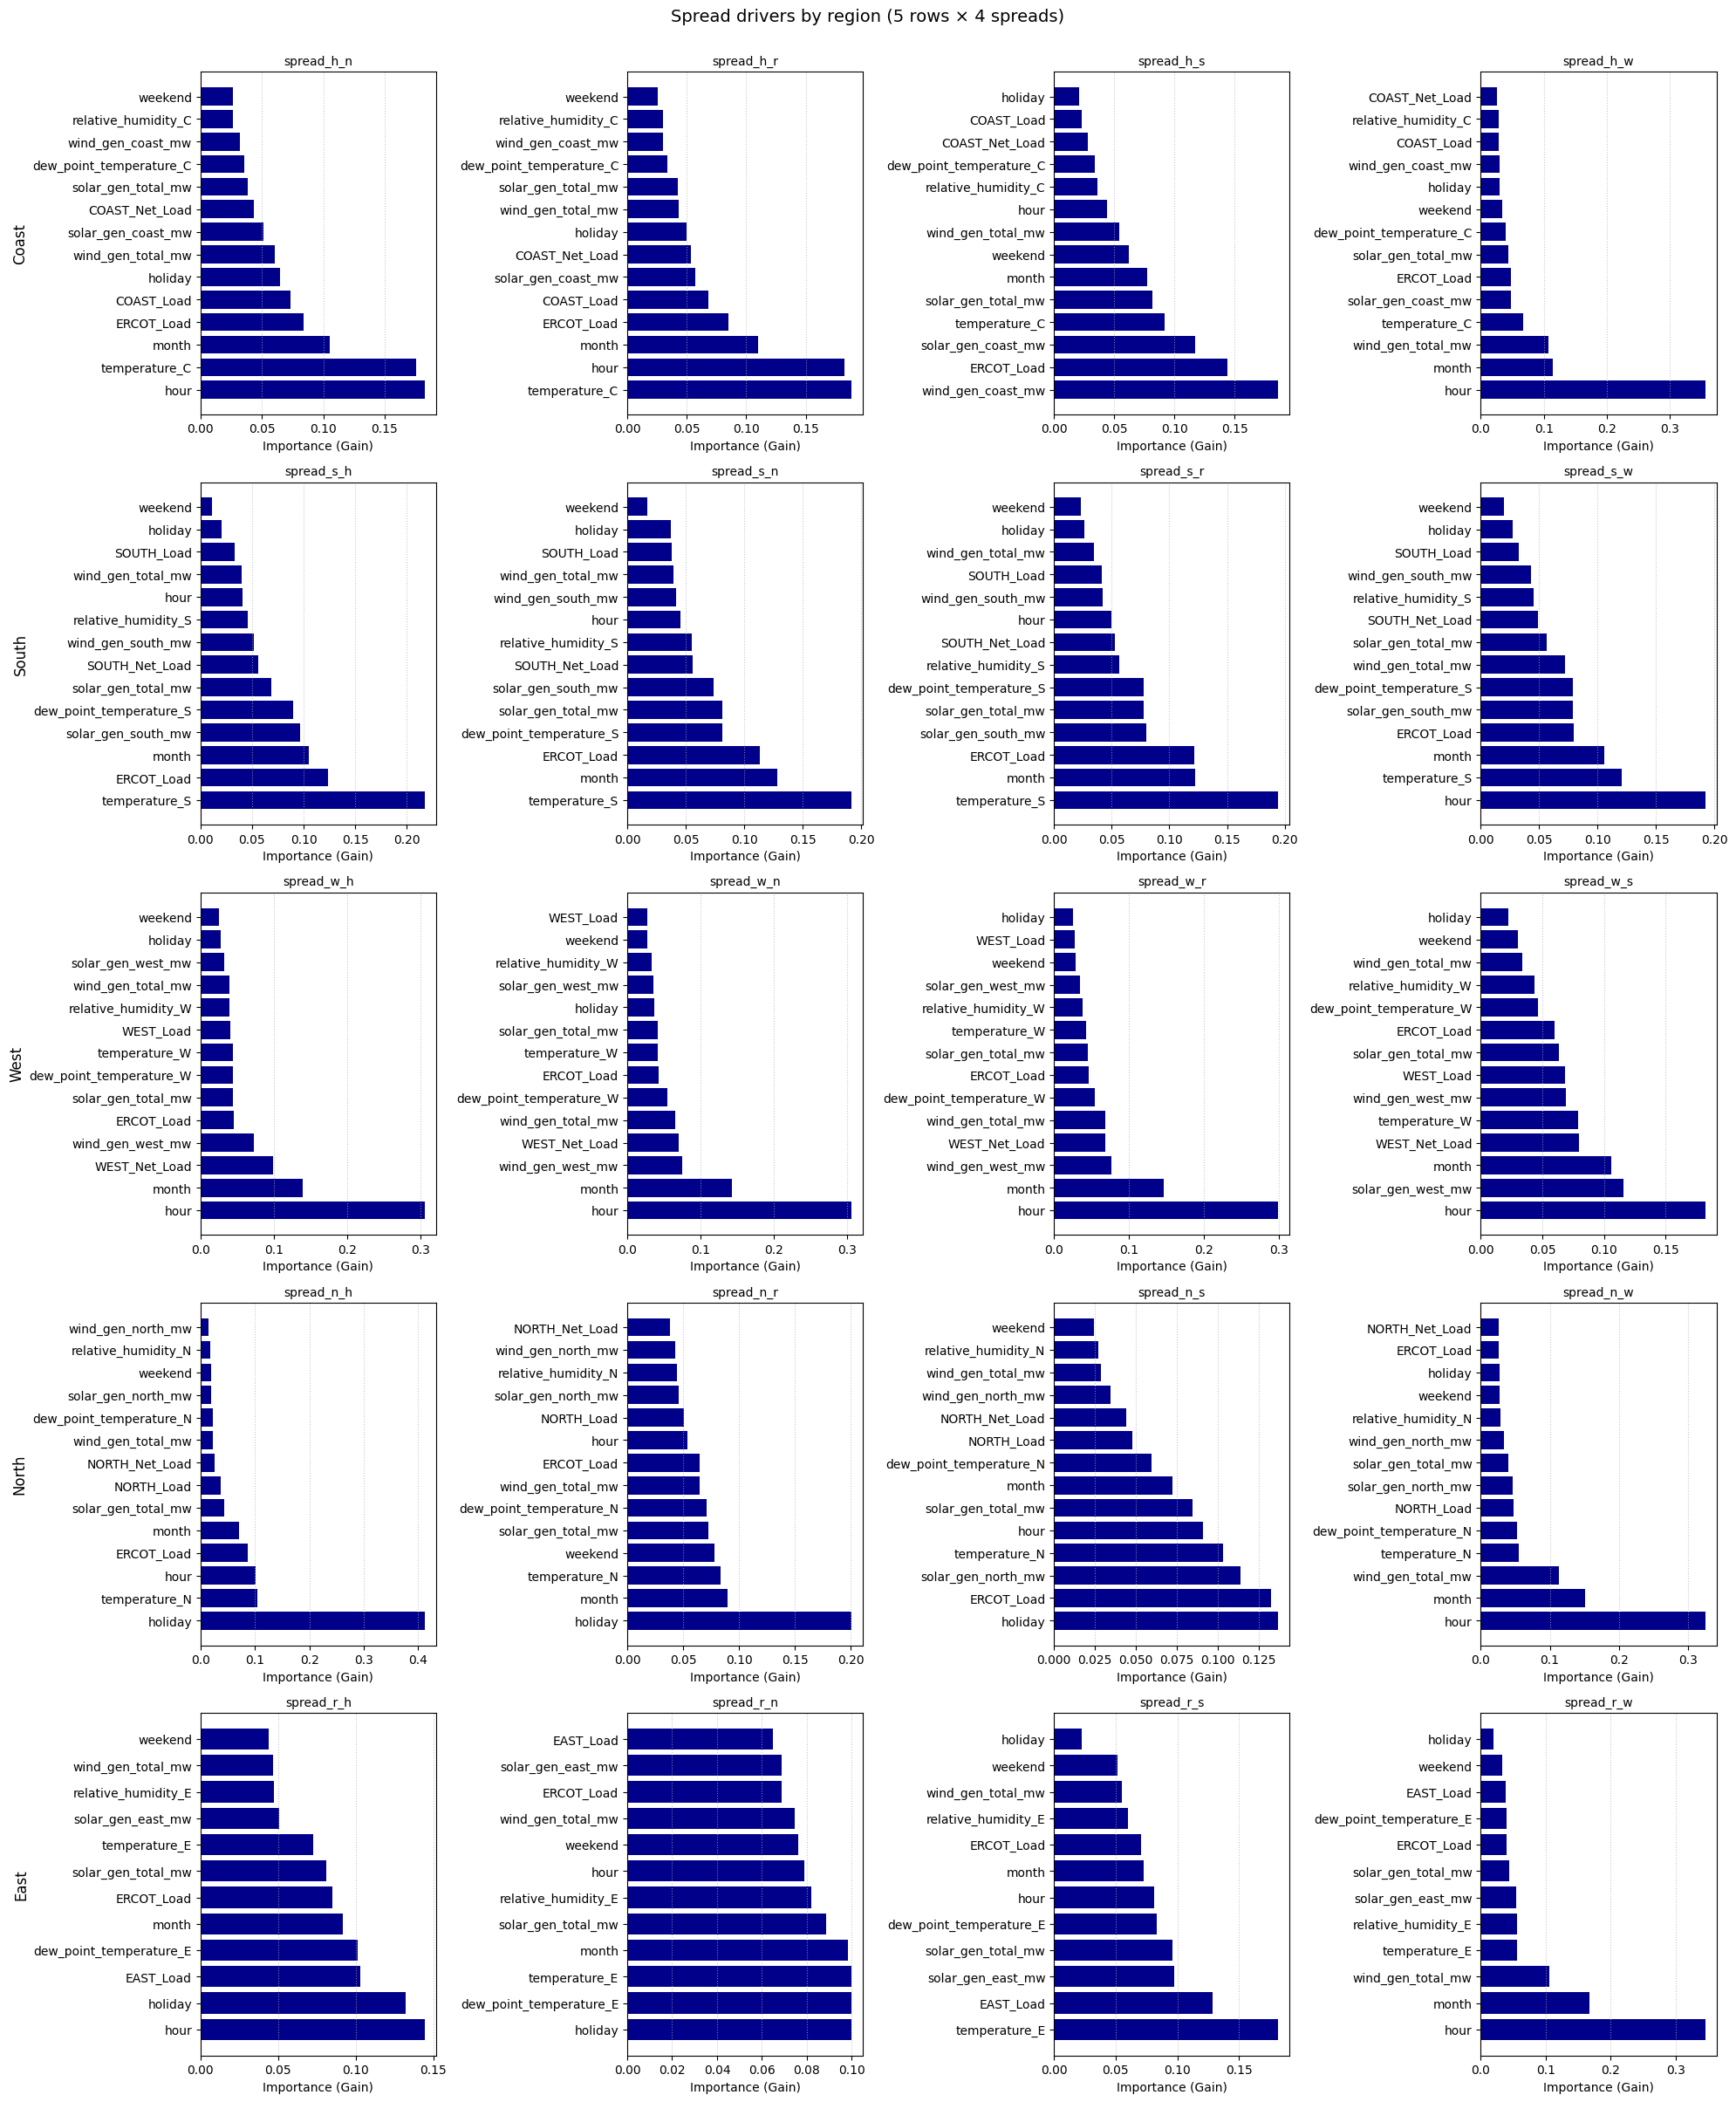

In [ ]:
# Container: region name -> regional DataFrame (must have spread_* columns and matching load/weather)
regions_container = {
    'coast': df_coast,
    'south': df_south,
    'west':  df_west,
    'north': df_north,
    'east':  df_east,
}

# One grid: 5 rows (regions) × 4 columns (spreads per region) = 20 visualizations
analyze_all_regions_spread_drivers(regions_container)
